In [1]:
import torch 
import torch.nn as nn

In [2]:
import numpy as np

In [3]:
from basemodel import *

In [4]:
from data_handler import *

In [5]:
from optimizer import *

In [6]:
from fit import *

In [7]:
import matplotlib.pyplot as plt

In [8]:
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import *

In [9]:
import cbs

In [10]:
from collections import OrderedDict

In [11]:
def save(path,results,names = ['normal','attack','disable','end','test']):
    for i in range(len(results)):
        np.save(path+names[i]+'.npy',results[i])

In [12]:
import random

In [13]:
import pytorch_ssim

# Data

In [14]:
trn_ , val_ = split('../dataset/fuz attack/lka_can/normal/bin/',prc = 0.2, dataset_pct=  1, dim =(112,112), word_type=torch.float)
normal , _ = split('../dataset/fuz attack/lka_can/attack/bin/',prc = 0 , dataset_pct=  1, dim = (112,112), word_type=torch.float)
atk , _ = split('../dataset/fuz attack/lka_can/attack/bin/',prc = 0 , dataset_pct=  1, dim = (112,112), word_type=torch.float)

In [15]:
trn_.data= trn_.data[80*220:]

In [16]:
normal.data = trn_.data + val_.data
atk.data = trn_.data + val_.data+ atk.data

In [17]:
bs = 8
seq_len = 10
overlap=0

In [18]:
trn_dl = Sequence_dl( trn_, bs=bs,seq_len=seq_len,overlap = overlap, num_workers=4,drop_last=True,dim=[112,112])
val_dl = Sequence_dl( val_, bs=bs,seq_len=seq_len,overlap = overlap, num_workers=4,drop_last=True,dim=[112,112])

In [19]:
normal_dl = Sequence_dl( normal, bs=bs,seq_len=seq_len,overlap =overlap,num_workers=4,drop_last=True,dim=[112,112])
anml_dl = Sequence_dl( atk, bs=bs,seq_len=seq_len,overlap =overlap,num_workers=4,drop_last=True,dim=[112,112])

In [20]:
dl =CombineDataLoader(trn_dl,val_dl)

# Custom Loss

In [21]:
class SSIM:
    def __init__(self):
        self.ssim_loss = pytorch_ssim.SSIM(window_size = 11)
    def __call__(self,ip,tgt):
        
        if type(ip[-1]) == torch.Tensor:
            tgt_lka,tgt_vis,ip_lka,ip_vis,tgt_hist,ip_hist = ip
            
            tgt_vis = tgt_vis [None,None,None,:]
            ip_vis = ip_vis [None,None,None,:]
            tgt_hist = tgt_hist [None,None,:,:]
            ip_hist = ip_hist [None,None,:,:]
            
            
            vis = self.ssim_loss(ip_vis,tgt_vis)
            lka = 0#nn.functional.binary_cross_entropy(ip_lka[:88],tgt_lka[:88])
            hist = self.ssim_loss(ip_hist,tgt_hist)

            return 1 - (lka+vis*0.5+hist*0.5)            
        
        else:
            tgt_lka,tgt_vis,ip_lka,ip_vis,_,_ = ip
            
            tgt_vis = tgt_vis [None,None,None,:]
            ip_vis = ip_vis [None,None,None,:]

            
            vis = self.ssim_loss(ip_vis,tgt_vis)
            lka = 0#nn.functional.binary_cross_entropy(ip_lka[:88],tgt_lka[:88])
            
            return 1 - (lka+vis)
        

In [22]:
class binary:
    def __call__(self,ip,tgt):     
        if type(ip[-1]) == torch.Tensor:
            tgt_lka,tgt_vis,ip_lka,ip_vis,tgt_hist,ip_hist = ip
           
            vis = nn.functional.binary_cross_entropy(ip_vis[:88],tgt_vis[:88])
            lka = 0#nn.functional.binary_cross_entropy(ip_lka[:88],tgt_lka[:88])
            hist = nn.functional.binary_cross_entropy(ip_hist,tgt_hist)
    
            return (lka+vis*0.5+hist*0.5)            
        
        else:
            tgt_lka,tgt_vis,ip_lka,ip_vis,_,_ = ip
            
            vis = nn.functional.binary_cross_entropy(ip_vis[:88],tgt_vis[:88])
            lka = 0#nn.functional.binary_cross_entropy(ip_lka[:88],tgt_lka[:88])
            
            return (lka+vis)

In [23]:
class binary:
    def __call__(self,ip,tgt):
            tgt_lka,ip_lka = ip    
            lka = nn.functional.binary_cross_entropy(ip_lka,tgt_lka)
            return lka

In [24]:
class mse:
    def __call__(self,ip,tgt):
            tgt_lka,ip_lka = ip    
            l = 0#nn.functional.mse_loss(ip,tgt)
            lka = nn.functional.mse_loss(ip_lka,tgt_lka)
            
            return lka

In [25]:
loss = mse()

## Helping Methods

In [26]:
def get_vis(frame):
    new_frame = frame.type(torch.int).tolist()
    new_frame = [str(i) for i in new_frame]
    s = ''.join(new_frame)
    new_frame = s[-4:] + s[:8]
    
    return (int(new_frame,2) *0.01)-16

In [27]:
def get_frame(value):
    
    value = int((value +16 ) / 0.01)
    
    hex_value = hex(value)[2:]
    bin_value = bin(int(f"{hex_value}", 16))[2:].zfill(12)
    
    new_frame = bin_value[-8:] + bin_value[:4]
    new_frame = [float(i) for i in list(new_frame)]
    new_frame = torch.tensor(new_frame)
    return new_frame

In [28]:
vis = np.load('../dataset/fuz attack/generated_ds/amr/array.npy')

# Model : Predict LKA
Input: VIS History + Previous VIS + VIS <br>
Input Form: Full frame<br>
Output: Prediction   LKA <br>
Training Dataset: Original<br>

In [29]:
import random

In [30]:
from baseline import*

In [32]:
class lka_lstm_predictor(BaseModel):    
    def __init__(self,seq_len):
        super().__init__()
        self.seq_len= seq_len
        
        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
        
        self.vis = torch.tensor([0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0.,
         0., 0., 1., 1., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0.,
         1., 0., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 0., 1., 0.,
         0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 1., 1., 1., 1., 0., 1., 1., 0.,
         0., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0., 1.]).cuda()
        
        
        
        self.ip_lstm = nn.LSTM(2,self.seq_len)
        
        self.lka_predictor = nn.Sequential(nn.Linear(self.seq_len,1),
                                            nn.Sigmoid())
        
        
        
        

        self.drop = nn.Dropout(0.5)
        self.flag_list = []

        self.lka = torch.zeros(1).cuda()
        self.vis_value = torch.tensor(0.4).cuda()
        
        self.lka_list = [0]*10
        self.vis_list=[0.4]*9
        
        self.c =0
        self.art_lka = []
        self.test = True
        self.max_count= 2352
        
        self.count = 0
        self.gen_vis = []
        
        self.bias = 0
        self.b = 0
        
    def forward(self,x): 
        #self.lka = torch.zeros(1).cuda()
        input_list = x.view(80,-1).detach().cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:208] == self._289).sum(dim=1) // 88) == 1)[0]
        
        if vis_idx.size and not self.test :
            self.count = (self.count+1)%836            
            self.vis_value = (self.gen_vis[self.count] + self.bias) /4 
              
        elif vis_idx.size:   
            self.count = (self.count+1)%836
            self.vis = x.view(80,-1)[vis_idx[0]][120:208]
            self.vis_value =( get_vis(self.vis[28:28+16].data) + self.b)/4
            
                
        if self.c==0 and not self.test:
            self.bias = 0
            self.art_lka = []
            idx = random.randint(0,3)
            self.art_lka.extend( torch.randint(0,400,(1,(idx*2)+1)).tolist()[0])
            self.art_lka.extend( torch.randint(740,850,(1,random.randint(0,2))).tolist()[0])
            #self.art_lka.extend( torch.randint(510,570,(1,random.randint(0,2))).tolist()[0])
            print(self.art_lka)
            
            

        if self.c in self.art_lka:
            print('transition')
            self.lka =torch.logical_xor(self.lka.type(torch.BoolTensor),torch.ones_like(self.lka).type(torch.BoolTensor)).type(torch.FloatTensor).cuda()
        #Update VIS list
        self.vis_list.append(self.vis_value)
        
        #LSTM
        ip = torch.stack([torch.tensor(self.lka_list[-self.seq_len:]).type(torch.FloatTensor).cuda(),torch.tensor(self.vis_list[-self.seq_len:]).type(torch.FloatTensor).cuda()]).T
        
        _,ip_lstm = self.ip_lstm(self.drop(ip.view(self.seq_len,1,2))) 
        last_hidden_state = ip_lstm[0].view(-1)
        
        predected_lka = self.lka_predictor(last_hidden_state)
        
        
            
        self.lka_list.append(self.lka.detach().data)
        

        self.flag_list.append([self.lka.detach().cpu(),self.vis.detach().cpu(),self.vis_value])
        self.c = (self.c + 1) % self.max_count
        return self.lka.type(torch.FloatTensor).cuda(),predected_lka

In [31]:
m =  simple_predictor(10).cuda()

In [32]:
opt = torch.optim.Adam(m.parameters(),1e-4)
opt = BaseOptimizer(opt)
learn = learner()

In [33]:
trn_item = Validate(trn_dl)
val2_item = Validate(val_dl)
normal_item = Validate(normal_dl)
anml_item = Validate(anml_dl)

In [34]:
#cbs.load_all('publication/enhanced predict lka/temp',learn = learn,model=m ,opt=opt)

In [35]:
m.gen_vis = np.load('../dataset/fuz attack/generated_ds/amr/array.npy')
m.test = False
m.max_count = len(trn_dl)+len(val_dl)

In [36]:
sum(p.numel() for p in m.parameters())

563

In [38]:
loss =mse()

In [38]:
learn.fit(m , opt , 4 , dl,loss  )

  1%|▏         | 23/1837 [00:00<00:20, 90.46it/s, loss : 0.23263352850209112]

[0, 225, 52, 50, 266, 767]
transition


  4%|▍         | 77/1837 [00:00<00:14, 119.56it/s, loss : 0.2364542329466188] 

transition
transition


 13%|█▎        | 243/1837 [00:01<00:11, 136.29it/s, loss : 0.23116260104709202]

...

transition


 46%|████▌     | 848/1837 [00:06<00:10, 91.21it/s, loss : 0.04802579249975816]  

transition


 98%|█████████▊| 506/515 [00:03<00:00, 139.72it/s, loss : 0.002965073811678076]  

train Loss:  0.0269166249781847   validation loss:  0.0029633028898388147
tensor(nan)


In [37]:
m.test = True
m.max_count =  len(anml_dl)
m.lka = torch.zeros(1).cuda()
l1 = range(250,3500,100)
l = [[],[400],[250,400,1000,2400],[1000,1500],[1500],[2400],l1]
m.art_lka = l[-1]#range(0,3500,50)
m.c=0
m.b = 0.0

In [38]:
%%time
anml_item.evaluate(model = m , crit = loss)
#c = torch.tensor(anml_item.test_loss)#.median() # normal 

  0%|          | 0/3577 [00:00<?, ?it/s]/mnt/5e85af0b-fa6b-4dca-a539-449bff7060b4/العمل/logsagenttechnicaldepth/baseline.py:190: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  v = torch.tensor(self.vis_list[-1]).type(torch.FloatTensor).view(1,).cuda()
/mnt/5e85af0b-fa6b-4dca-a539-449bff7060b4/العمل/logsagenttechnicaldepth/baseline.py:189: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  l = torch.tensor(self.lka_list[-1]).type(torch.FloatTensor).view(1,).cuda()
  0%|          | 10/3577 [00:00<00:37, 95.53it/s]

testing...


  8%|▊         | 277/3577 [00:02<00:23, 140.17it/s]

transition


 11%|█         | 378/3577 [00:02<00:22, 140.97it/s]

...

transition


 97%|█████████▋| 3469/3577 [00:24<00:00, 140.42it/s]

transition


100%|█████████▉| 3567/3577 [00:25<00:00, 136.74it/s]

CPU times: user 13.4 s, sys: 2.71 s, total: 16.1 s
Wall time: 25.7 s


In [39]:
len(anml_dl)

3577

In [41]:
lka = [i[0][0]for i in m.flag_list]
vis = [i[-1]for i in m.flag_list]

In [42]:
len(anml_dl)

3577

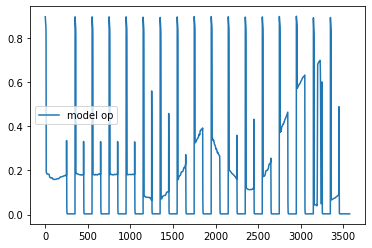

In [43]:
fig,ax = plt.subplots()

#ax.plot(range(len(vis[-3577:])),vis[-3577:],label='RLD')
#ax.plot(range(len(lka[-3577:])),lka[-3577:],label='lka')
ax.plot(range(len(c)),c,label='model op')
ax.legend()

In [41]:
#fig.savefig('Models/publication/recon_hist_vis/bce/15/i.png',dpi=300)

In [42]:
#np.save('Models/publication/recon_hist_vis/bce/15/attack.npy',c)

In [43]:
#fig.savefig('Documents/case7.png')

In [46]:
b=c

In [50]:
c = 0
l = []
for i in b:
    c+=1
    if  i > 0.25 :
        l.append(i)


In [51]:
len(l)

33

In [53]:
l = l[0::2]

In [54]:
q=np.array(l)[0:5].max()
w=np.array(l)[0:5].min()

In [55]:
(np.array(l) <= q) == (np.array(l) >= w)

array([ True,  True,  True,  True,  True, False, False, False, False,
       False, False, False, False, False, False, False, False])

In [60]:
c = 0
l = []
for i in b:
    c+=1
    if  i > 0.25 :
        l.append(i)


In [61]:
l = l[1::2]

In [62]:
r=np.array(l)[0:4].max()
t=np.array(l)[0:4].min()

In [63]:
(np.array(l) <= r) == (np.array(l) >= t)

array([ True,  True,  True,  True, False, False, False, False, False,
       False, False, False, False, False, False, False])

In [44]:
cbs.save_all('Models/publication/lka_lstm_predictor/temp',learn = learn,model=m ,opt=opt)

In [45]:
loss = mse()

In [41]:
lka_list = []
vis_list = []
op_list = []
for i in range(1,8,1):
    m =  lka_lstm_predictor(10).cuda()
    cbs.load_all('publication/lka_lstm_predictor/temp',model=m,opt=opt,learn=learn)
    m.test = True
    m.max_count = len(anml_dl)
    m.vis = torch.tensor([0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0.,
         0., 0., 1., 1., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0.,
         1., 0., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 0., 1., 0.,
         0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 1., 1., 1., 1., 0., 1., 1., 0.,
         0., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0., 1.]).cuda()
    m.art_lka = l[i-1]
    
    anml_item.evaluate(model = m , crit = loss)
    op_list.append( torch.tensor(anml_item.test_loss))#.median() # Anomaly 
   
    lka_list.append([i[0][0]for i in m.flag_list])
    vis_list.append([i[-1]for i in m.flag_list])
    
    #fig,ax = plt.subplots()
    #ax.plot(range(len(b)),list(b),label='model op')
    

    #ax.plot(range(len(lka[-3576:])),lka[-3576:],label='lka')
    #ax.plot(range(len(vis[-3576:])),vis[-3576:],label='vis')
    #ax.plot(range(len(lka)),lka,label='lka')
    #ax.legend()

    
    #path = f'Models/publication/recon_hist_dec_vis/mse/{i}/'
    #fig.savefig(f'{path}i.png',dpi=300,,bbox_inches = 'tight',pad_inches=0.1)
    #save(path,[b],names=['attack'])

  0%|          | 7/3577 [00:00<00:52, 68.26it/s]

testing...


  0%|          | 8/3577 [00:00<00:47, 75.18it/s]/s]

testing...


 12%|█▏        | 424/3577 [00:03<00:24, 128.24it/s]

...

 94%|█████████▍| 3370/3577 [00:27<00:01, 122.18it/s]

transition


 97%|█████████▋| 3469/3577 [00:28<00:00, 115.95it/s]

transition


100%|█████████▉| 3576/3577 [00:29<00:00, 129.96it/s]

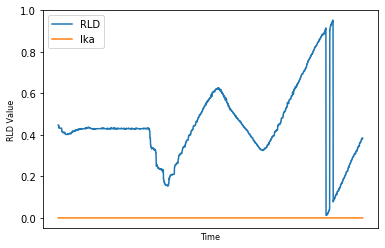

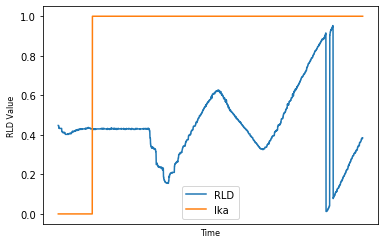

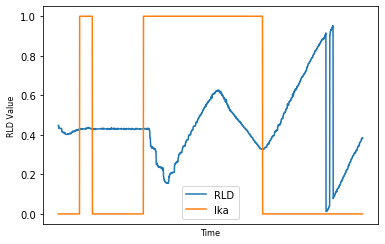

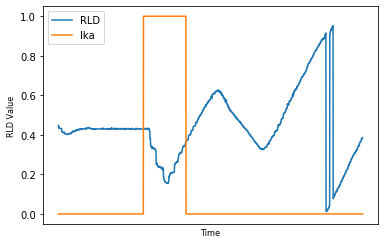

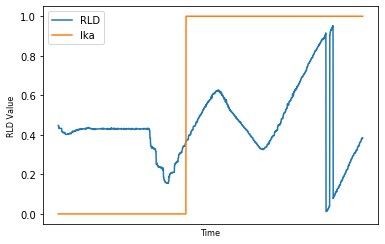

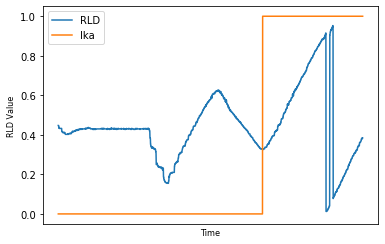

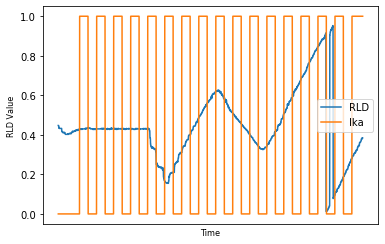

In [51]:
d = 1
#label = ['a','b','c','d','e','f','g','h','i']
for i in range(len(op_list)):
    fig,ax = plt.subplots()
    plt.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False) # labels along the bottom edge are off
    
    ax.set_xlabel("Time",fontsize=8)
    ax.set_ylabel("RLD Value",fontsize=8)
    #plt.xlabel(f'({label[i-1]})',fontsize=18)
    #plt.yticks(ticks=[])
    #ax.plot(range(len(op_list[i][1:])),list(op_list[i][1:]),label='model op')
    ax.plot(range(len(vis_list[i][1:])),vis_list[i][1:],label='RLD')
    ax.plot(range(len(lka_list[i])),lka_list[i],label='lka')
    ax.legend()
    #path = 'Models/publication/lka_lstm_predictor/mse/'
    #fig.savefig(f'{path}{d+i}/i.png' , format = 'png' , dpi=500,bbox_inches = 'tight',pad_inches=0.1)
    #np.save(f'{path}{d+i}/attack.npy',op_list[i])
    np.save(f'Documents/Experiments/vis{d+i}.npy',vis_list[i][1:])
    np.save(f'Documents/Experiments/lka{d+i}.npy',lka_list[i])

In [62]:
len(op_list)

7